# 10 · Comparing methods on all records

**Question.** Which settings of EPDE, and which classical sparse regression,
recover the equation most reliably, by class of problem and noise level?

**Protocol.** One shared token pool for every problem; files of the records add
only what is necessary. The compared variants are listed in the configuration
printed below.

**Metrics.** *Truth on the front*: some equation of the final Pareto front has
exactly the true set of terms (coefficients are not compared; documented
equivalent forms count). *Compromise pick*: one equation chosen from the front
without knowing the truth (smallest sum of normalised objectives).

**Running.** A campaign runs every combination of record, variant, noise level and
seed, each in its own process, and resumes after an interruption. It is started
from the command line (commands in the next cell) or from the app. The tables below
come from a small campaign: 10 records, three methods, noise 0 and 5 %, two seeds.
The full grid with all core records, more variants, noise levels and seeds takes
hours.

The tables below are historical saved outputs from a 120-run campaign with two seeds: 116 completed records and four unsupported baseline cells. They have not been re-scored with the coefficient-parser correction in this working copy. Raw campaign records are required for that recalculation. A method recovering a law for at least one seed is a different success rate from recovery per run, and a correct equation is different from recovery of an entire system. Compare methods only on their common supported records, and report unsupported cells separately.

In [ ]:
# From a terminal, in the repository root:
#   python projects/pic/bench.py campaign --datasets ode,vdp,duffing,lv,burgers,wave,ac,kdv_cossin,pde_compound,pde_divide \
#          --variants default,legacy,pysindy --noise 0,5 --seeds 0-1 --workers 10 --name comparison
#   python projects/pic/bench.py report projects/pic/results/comparison

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

EPDE imported; notebook environment ready


In [2]:
print((PIC / 'configs' / 'variants.yaml').read_text())

# Method variants compared by the benchmark. Each entry is merged on top of the
# shared protocol and the file of the record. The default variant changes
# nothing: EPDE as shipped (percentage discrepancy, instability as the second
# Pareto axis, variance-weighted sparsity) with the finite differences of the
# shared protocol.

default: {}

# Old EPDE: L2 discrepancy, LASSO sparsity, complexity as the second axis
# (the earlier pipeline of the group's former benchmark).
legacy:
  search:
    objectives:
      discrepancy_metric: l2
      sparsity_cls: lasso
      sparsity_kwargs: {initial_sparsity_interval: [1.0e-12, 1.0e-4]}
      second_objective: complexity

# Derivatives from local polynomial fits instead of finite differences.
poly:
  search:
    preprocessing:
      default_preprocessor_type: poly

# Support chosen by the knee of the residual-vs-size curve.
knee:
  search:
    objectives:
      sparsity_cls: knee

# Instability measured by cross-validation over windows.
instab_cv

In [3]:
import pandas as pd
from IPython.display import Markdown, display, Image
from epde_bench.paths import RESULTS_DIR
CAMPAIGN = RESULTS_DIR / os.environ.get('EPDE_BENCH_NOTEBOOK_CAMPAIGN', 'comparison')
print('campaign results available:', (CAMPAIGN / 'runs').exists())

campaign results available: True


report written to C:\Users\maksi\epde_work\EPDE_rev\projects\pic\results\comparison\report


# Campaign `comparison`

Runs: 120 (ok: 116, unsupported: 4).
Success: the true structure (or an accepted equivalent form) is on the final Pareto front; "pick": the equation chosen from the front without knowing the truth (compromise) is correct. Cells: k/n (rate, 95 % Wilson interval). Errors and timeouts count as misses. pending: planned, not yet run; unsupported: the method cannot represent the problem. These two statuses are excluded from the denominators.

## Noise 0 %

### Truth on the Pareto front

| dataset | default | legacy | pysindy |
|---|---|---|---|
| ac | 2/2 (100%, 34-100) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| burgers | 2/2 (100%, 34-100) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| duffing | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| kdv_cossin | 2/2 (100%, 34-100) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| lv | 1/2 (50%, 9-91) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| ode | 2/2 (100%, 34-100) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| pde_compound | 2/2 (100%, 34-100) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| pde_divide | 2/2 (100%, 34-100) | 0/2 (0%, 0-66) |  |
| vdp | 2/2 (100%, 34-100) | 1/2 (50%, 9-91) | 2/2 (100%, 34-100) |
| wave | 2/2 (100%, 34-100) | 1/2 (50%, 9-91) | 2/2 (100%, 34-100) |

### Compromise pick is correct

| dataset | default | legacy | pysindy |
|---|---|---|---|
| ac | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| burgers | 1/2 (50%, 9-91) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| duffing | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| kdv_cossin | 2/2 (100%, 34-100) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| lv | 1/2 (50%, 9-91) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| ode | 1/2 (50%, 9-91) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| pde_compound | 2/2 (100%, 34-100) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| pde_divide | 2/2 (100%, 34-100) | 0/2 (0%, 0-66) |  |
| vdp | 2/2 (100%, 34-100) | 0/2 (0%, 0-66) | 2/2 (100%, 34-100) |
| wave | 2/2 (100%, 34-100) | 1/2 (50%, 9-91) | 2/2 (100%, 34-100) |

## Noise 5 %

### Truth on the Pareto front

| dataset | default | legacy | pysindy |
|---|---|---|---|
| ac | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| burgers | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| duffing | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| kdv_cossin | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| lv | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| ode | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| pde_compound | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| pde_divide | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |  |
| vdp | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| wave | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |

### Compromise pick is correct

| dataset | default | legacy | pysindy |
|---|---|---|---|
| ac | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| burgers | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| duffing | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| kdv_cossin | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| lv | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| ode | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| pde_compound | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| pde_divide | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |  |
| vdp | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |
| wave | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) | 0/2 (0%, 0-66) |

## Best variant per problem class

Mean over the data sets of the class supported by every variant of the per-set success rate; a data set is left out of the ranking when any variant is unsupported on it or has no finished runs yet. Ties are broken by the compromise pick, then by speed.

| class | noise, % | best variant | success (front) | success (pick) | median time, s |
|---|---|---|---|---|---|
| ODE | 0 | pysindy | 67% | 67% | 3 |
| ODE | 5 | pysindy | 0% | 0% | 3 |
| ODE system | 0 | pysindy | 100% | 100% | 3 |
| ODE system | 5 | pysindy | 0% | 0% | 3 |
| PDE 1-D | 0 | default | 100% | 70% | 204 |
| PDE 1-D | 5 | pysindy | 0% | 0% | 24 |

## All data sets together (mean success on the front)

| variant | 0.0 | 5.0 |
|---|---|---|
| default | 83% | 0% |
| pysindy | 78% | 0% |
| legacy | 11% | 0% |

## Median search time, s

| dataset | default | legacy | pysindy |
|---|---|---|---|
| ac | 115.7 | 72.3 | 18.0 |
| burgers | 324.2 | 316.9 | 83.5 |
| duffing | 119.3 | 23.2 | 3.5 |
| kdv_cossin | 218.1 | 71.5 | 22.6 |
| lv | 94.2 | 95.2 | 3.3 |
| ode | 36.1 | 18.0 | 3.1 |
| pde_compound | 447.9 | 319.2 | 126.4 |
| pde_divide | 534.1 | 275.0 |  |
| vdp | 73.6 | 16.6 | 3.2 |
| wave | 168.6 | 70.0 | 21.5 |

## Pending and unsupported runs

- pde_divide / pysindy / noise 0 / seed 0: unsupported the baseline cannot represent x*u_t on the left-hand side and has no inverse-x coefficient token
- pde_divide / pysindy / noise 0 / seed 1: unsupported the baseline cannot represent x*u_t on the left-hand side and has no inverse-x coefficient token
- pde_divide / pysindy / noise 5 / seed 0: unsupported the baseline cannot represent x*u_t on the left-hand side and has no inverse-x coefficient token
- pde_divide / pysindy / noise 5 / seed 1: unsupported the baseline cannot represent x*u_t on the left-hand side and has no inverse-x coefficient token


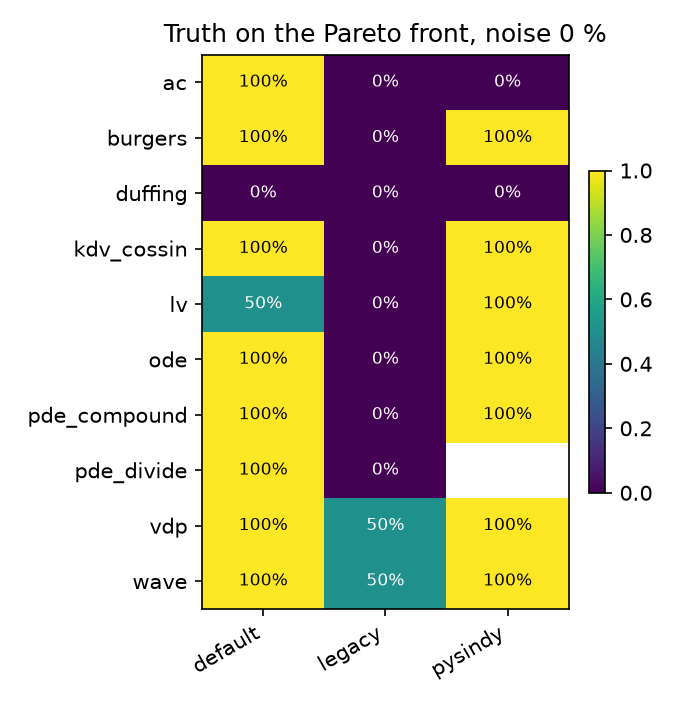

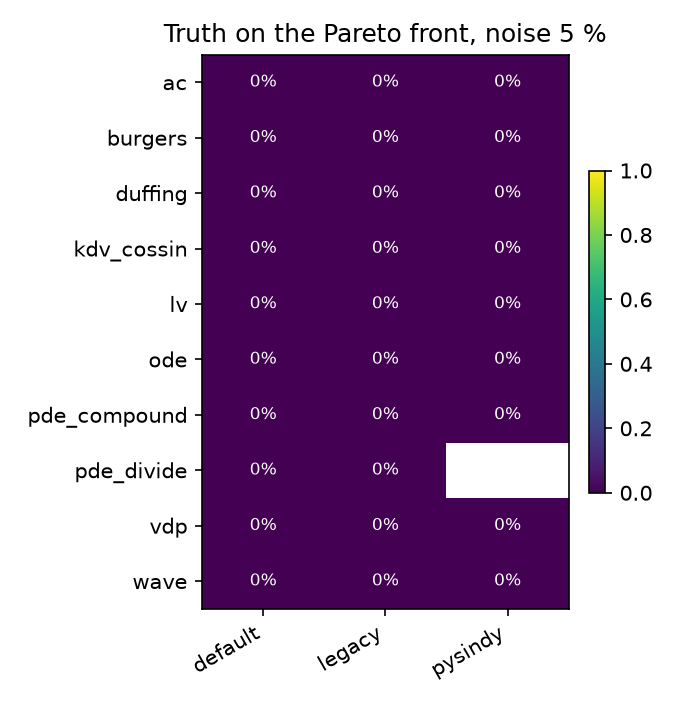

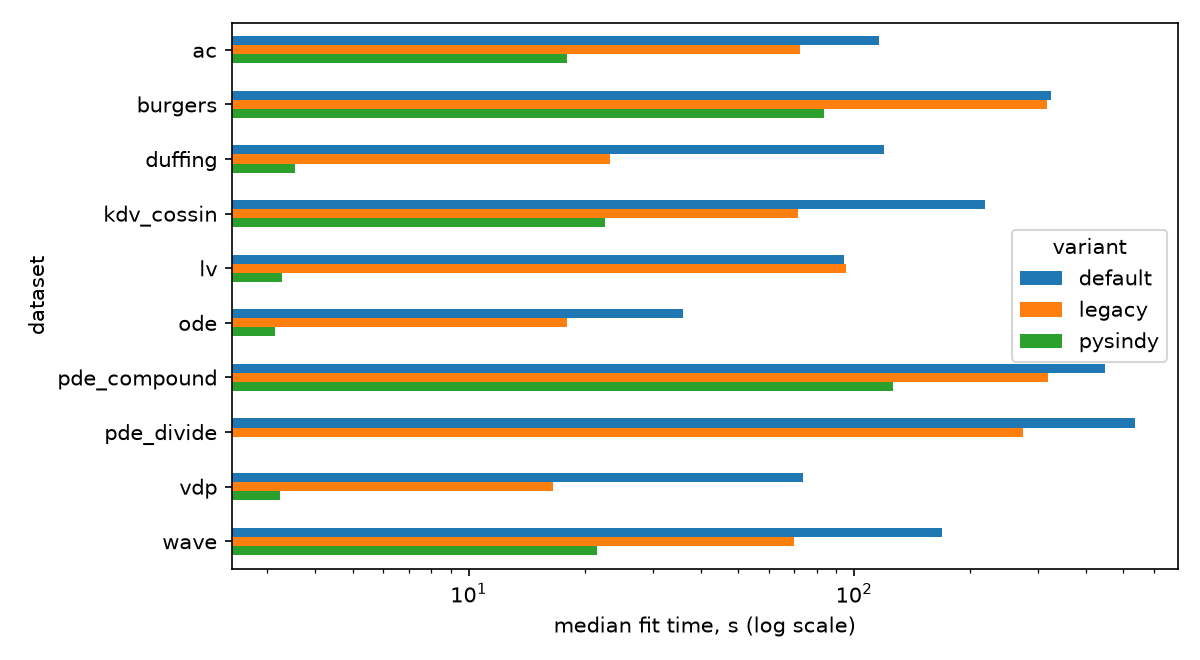

In [4]:
from epde_bench.report import make_report
if (CAMPAIGN / 'runs').exists():
    out = make_report(CAMPAIGN)
    display(Markdown((out / 'summary.md').read_text(encoding='utf-8')))
    for png in sorted((CAMPAIGN / 'report').glob('fig_*.png')):
        display(Image(filename=str(png)))
else:
    print('run the campaign first (commands above)')

In [5]:
# Pending and unsupported runs are reported separately, not as failures.
if (CAMPAIGN / 'report' / 'success_front.csv').exists():
    display(pd.read_csv(CAMPAIGN / 'report' / 'success_front.csv'))
    display(pd.read_csv(CAMPAIGN / 'report' / 'ranking.csv'))

,dataset,variant,noise,kind,runs,planned,pending,unsupported,success_front,success_selected,median_fit_s,median_coef_error,ranking_comparable
0,ac,default,0.0,pde_1d,2,2,0,0,1.0,0.0,103.319987,0.121761,True
1,ac,default,5.0,pde_1d,2,2,0,0,0.0,0.0,128.934447,NaN,True
2,ac,legacy,0.0,pde_1d,2,2,0,0,0.0,0.0,64.837148,NaN,True
3,ac,legacy,5.0,pde_1d,2,2,0,0,0.0,0.0,72.295120,NaN,True
4,ac,pysindy,0.0,pde_1d,2,2,0,0,0.0,0.0,17.285139,NaN,True
5,ac,pysindy,5.0,pde_1d,2,2,0,0,0.0,0.0,18.815305,NaN,True
6,burgers,default,0.0,pde_1d,2,2,0,0,1.0,0.5,204.094382,0.006912,True
7,burgers,default,5.0,pde_1d,2,2,0,0,0.0,0.0,440.677581,NaN,True
8,burgers,legacy,0.0,pde_1d,2,2,0,0,0.0,0.0,326.871104,NaN,True
9,burgers,legacy,5.0,pde_1d,2,2,0,0,0.0,0.0,287.973354,NaN,True


,kind,noise,variant,success_front,success_selected,median_fit_s
0,ode,0.0,pysindy,0.666667,0.666667,3.265582
1,ode,0.0,default,0.666667,0.500000,72.739125
2,ode,0.0,legacy,0.166667,0.000000,17.978768
3,ode,5.0,pysindy,0.000000,0.000000,3.195856
4,ode,5.0,legacy,0.000000,0.000000,17.317886
5,ode,5.0,default,0.000000,0.000000,75.988308
6,ode_system,0.0,pysindy,1.000000,1.000000,3.195045
7,ode_system,0.0,default,0.500000,0.500000,103.020415
8,ode_system,0.0,legacy,0.000000,0.000000,89.088926
9,ode_system,5.0,pysindy,0.000000,0.000000,3.346904
